In [10]:
import pandas as pd

# Load the datasets from the specified paths
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")



In [11]:
def compute_aa_composition(df, colname, group_label):
    aac = df[colname].apply(aa_composition).apply(pd.Series)
    aac["group"] = group_label
    return aac


In [12]:
from collections import Counter
import pandas as pd

from collections import Counter


## Code für balkendiagramme für Aminosäurezusammensetzung

In [18]:
def compute_aa_composition(df, colname, group_label):
    aac = df[colname].apply(aa_composition).apply(pd.Series)
    aac["group"] = group_label
    return aac

def plot_aa_composition(aac_sars, aac_influenza, aac_human, region_label="CDR-H3"):
    # Mittelwerte
    mean_sars = aac_sars.drop(columns="group").mean()
    mean_influenza = aac_influenza.drop(columns="group").mean()
    mean_human = aac_human.drop(columns="group").mean()

    df_plot = pd.DataFrame({
        "AminoAcid": mean_sars.index,
        "Corona": mean_sars.values,
        "Influenza": mean_influenza.values,
        "Human": mean_human.values
    })

    # Plot
    import matplotlib.pyplot as plt
    import numpy as np

    x = np.arange(len(df_plot["AminoAcid"]))
    width = 0.25

    plt.figure(figsize=(12, 6))
    plt.bar(x - width, df_plot["Corona"], width=width, label="Corona", color="pink")
    plt.bar(x,         df_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
    plt.bar(x + width, df_plot["Human"], width=width, label="Human", color="skyblue")

    plt.xticks(ticks=x, labels=df_plot["AminoAcid"])
    plt.ylabel("Relative Häufigkeit")
    plt.xlabel("Aminosäure")
    plt.title(f"Aminosäurezusammensetzung in {region_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


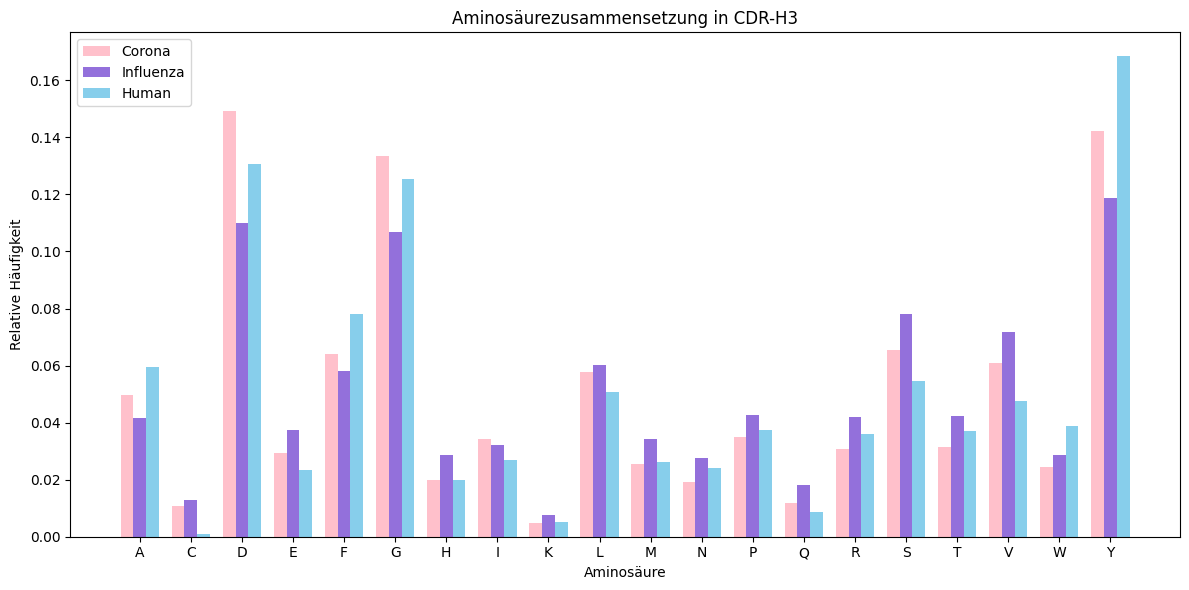

In [19]:
aac_sars_h3 = compute_aa_composition(df_corona, "CDR_H3", "Corona")
aac_influenza_h3 = compute_aa_composition(df_influenza, "CDR_H3", "Influenza")
aac_human_h3 = compute_aa_composition(df_human, "CDR_H3", "Human")

plot_aa_composition(aac_sars_h3, aac_influenza_h3, aac_human_h3, region_label="CDR-H3")


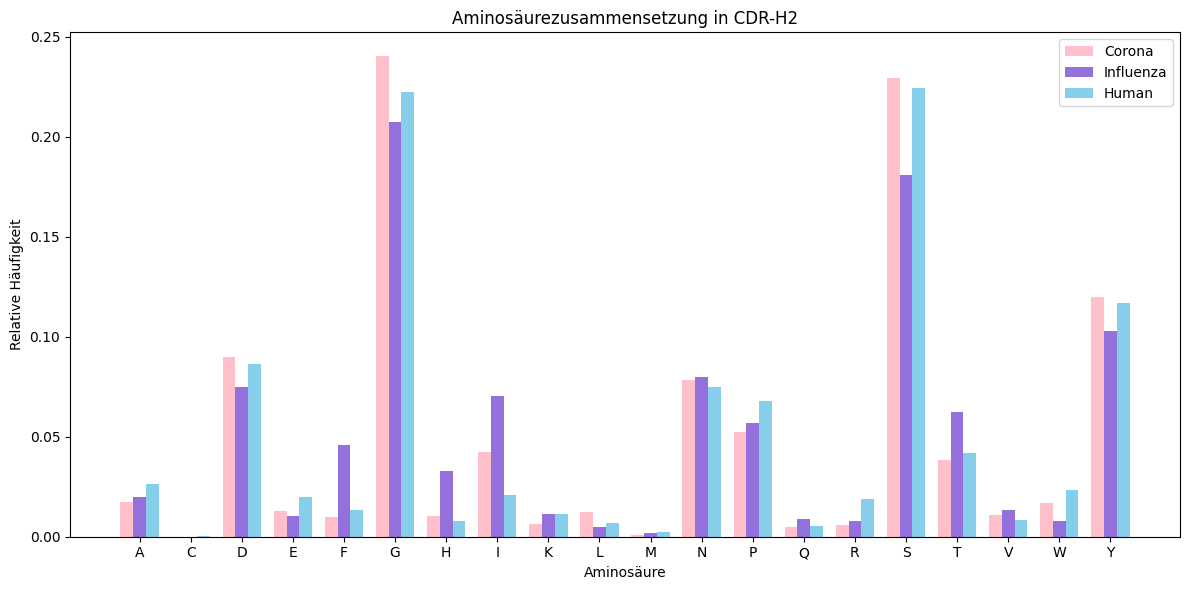

In [20]:
aac_sars_h2 = compute_aa_composition(df_corona, "CDR_H2", "Corona")
aac_influenza_h2 = compute_aa_composition(df_influenza, "CDR_H2", "Influenza")
aac_human_h2 = compute_aa_composition(df_human, "CDR_H2", "Human")

plot_aa_composition(aac_sars_h2, aac_influenza_h2, aac_human_h2, region_label="CDR-H2")


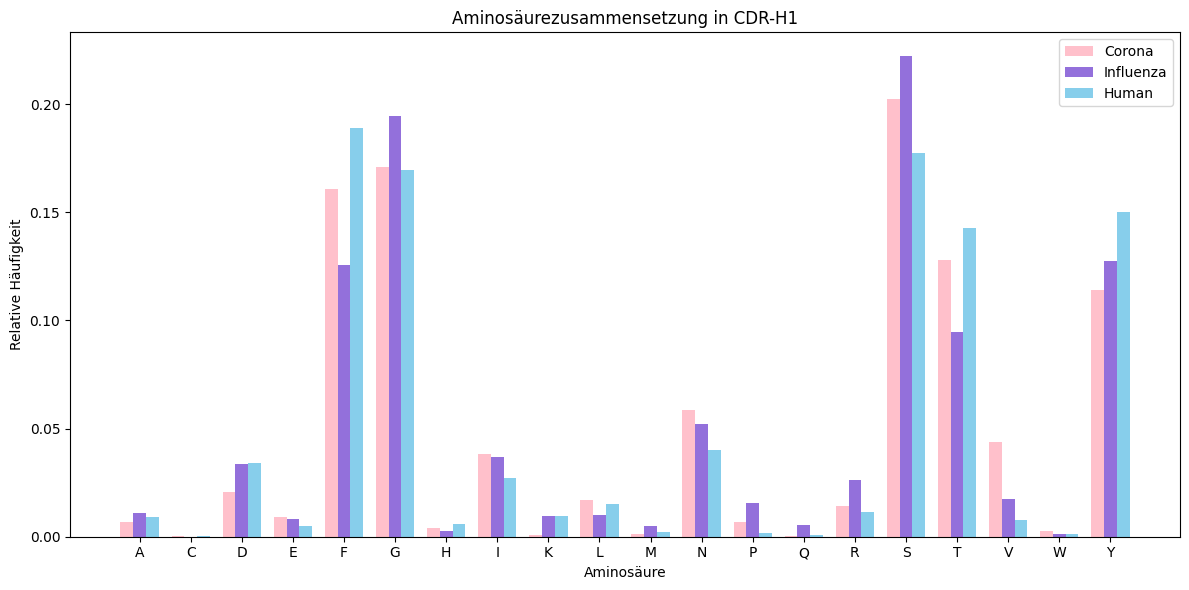

In [21]:
aac_sars_h1 = compute_aa_composition(df_corona, "CDR_H1", "Corona")
aac_influenza_h1 = compute_aa_composition(df_influenza, "CDR_H1", "Influenza")
aac_human_h1 = compute_aa_composition(df_human, "CDR_H1", "Human")

plot_aa_composition(aac_sars_h1, aac_influenza_h1, aac_human_h1, region_label="CDR-H1")


C:\Users\082mi\AppData\Local\Temp\ipykernel_62664\2022203506.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])


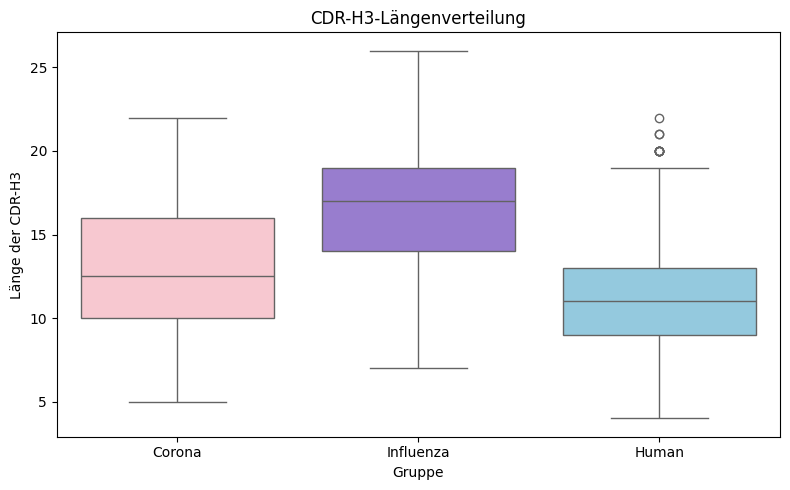

In [ ]:
import pandas as pd
# Load the datasets


df_corona["length"] = df_corona["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_corona["group"] = "Corona"

df_influenza["length"] = df_influenza["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_influenza["group"] = "Influenza"

df_human["length"] = df_human["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_human["group"] = "Human"

df_lengths = pd.concat([df_corona, df_influenza, df_human], ignore_index=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])
plt.title("CDR-H3-Längenverteilung")
plt.ylabel("Länge der CDR-H3")
plt.xlabel("Gruppe")
plt.tight_layout()
plt.show()

